# From explanations to executable model discovery

**Core hands-on notebook · 35–45 minutes**

A fluent explanation is not privileged access to a decision process. But it can become a useful **process-data channel** when we:

1. annotate what information and operations appear in the text;
2. test whether those annotations are reliable and behaviorally informative;
3. translate supported annotations into restricted candidate models;
4. compare those models on held-out decision problems.

We reuse the synthetic GPT-4 choice-and-reasoning records from Notebook 2. The final A/B conclusion was masked before Qwen representation analysis. Here we also truncate each trace before its first explicit preference claim.

> Annotation can constrain one model-discovery route; discovery does not require annotation, and annotation does not reveal the true mechanism by itself.

## 0. Setup

The default path is offline and lightweight. It reads the cached sentence-level table produced for Notebook 2. **All bundled results use the transparent lexical baseline.** Optional GLM or DeepSeek annotation is disabled unless you explicitly turn it on; DeepSeek V4 was not used to generate the reported numbers.

In [1]:
from pathlib import Path
import json
import os
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, log_loss
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 3000
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def find_sentence_table():
    relative = Path(
        "results/representation/text2decision_multiscale_log_trajectories/"
        "sentence_decision_states.csv"
    )
    candidates = [
        relative,
        Path("notebooks") / relative,
        Path("/content/LLM_human_decisions/notebooks") / relative,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Could not find sentence_decision_states.csv. Keep the notebooks/results folder "
        "with the tutorial materials."
    )


SENTENCE_PATH = find_sentence_table()
sentences = pd.read_csv(SENTENCE_PATH)
sentences["sentence_text"] = sentences["sentence_text"].fillna("")
sentences["is_masked_conclusion"] = (
    sentences["is_masked_conclusion"].astype(str).str.lower().eq("true")
)

print(f"Sentence rows: {len(sentences):,}")
print(f"Trials: {sentences['trial_row'].nunique():,}")
print(f"Questions: {sentences['question_id'].nunique()}")
print(f"Personas: {sentences['persona'].nunique()}")

Sentence rows: 11,642
Trials: 1,368
Questions: 19
Personas: 5


## 1. What exactly are we annotating?

The unit is one sentence, but the trace remains ordered. We separate three axes:

- **attended information:** expected value, probabilities, downside, upside, certainty, risk;
- **operation:** describe, compute, compare, or consider a counterfactual;
- **evidential role:** supports A, supports B, neither, or an explicit preference claim.

The final axis is essential for leakage control: explicit preference statements are excluded before downstream evaluation.

In [3]:
OPTION = r"option\s+[ab]"
DECISIVE = (
    r"(?:choose|chose|select|pick|lean(?:ing)?|inclined|opt(?:ing)?|"
    r"go with|would take|will take|my choice|my decision|prefer)"
)
EXPLICIT_PATTERN = re.compile(
    rf"(?i)(?:{OPTION}.{{0,120}}\b{DECISIVE}\b|"
    rf"\b{DECISIVE}\b.{{0,120}}{OPTION}|"
    rf"\b{OPTION}\b.{{0,80}}(?:appealing|attractive).{{0,40}}(?:to me|for me))"
)


def is_explicit_claim(text):
    return "Option X" in text or bool(EXPLICIT_PATTERN.search(str(text)))


def retain_preference_free_prefix(frame):
    frame = frame.sort_values("sentence_index").copy()
    flags = frame["sentence_text"].map(is_explicit_claim).to_numpy()
    cutoff = int(np.flatnonzero(flags)[0]) if flags.any() else len(frame)
    return frame.iloc[:cutoff]


retained = pd.concat(
    [
        retain_preference_free_prefix(frame)
        for _, frame in sentences.groupby("trial_row", sort=False)
    ],
    ignore_index=True,
)

audit = pd.DataFrame({
    "all_sentences": sentences.groupby("trial_row").size(),
    "retained_before_claim": retained.groupby("trial_row").size(),
}).fillna(0)
audit["removed"] = audit["all_sentences"] - audit["retained_before_claim"]
display(audit.describe().round(2))

,all_sentences,retained_before_claim,removed
count,1368.00,1368.00,1368.00
mean,8.51,7.04,1.47
std,1.81,2.01,1.16
min,4.00,1.00,1.00
25%,7.00,6.00,1.00
50%,8.00,7.00,1.00
75%,10.00,8.00,1.00
max,20.00,19.00,9.00


In [4]:
example_trial = int(
    retained.loc[
        (retained["question_id"] == "Q01")
        & (retained["persona"] == "Rational Decision-Maker"),
        "trial_row",
    ].iloc[0]
)
example = retained.loc[retained["trial_row"] == example_trial].sort_values("sentence_index")
print(example["question"].iloc[0])
display(example[["sentence_index", "sentence_text"]])

Which option do you prefer? Option A: 1000.0 dollars with 25.0 % chance, 0.0 dollars with 75.0 % chance. Option B: 240.0 dollars with 100.0 % chance.


,sentence_index,sentence_text
244,0,Let's analyze both options.
245,1,Option A gives a 25% chance of winning $1000 and a 75% chance of winning nothing.
246,2,"To determine the expected value, we can multiply each outcome by its probability and sum them up."
247,3,"The expected value of option A is (0.25 * 1000) + (0.75 * 0), which equals $250."
248,4,"Option B gives a 100% chance of winning $240, which means the expected value is simply $240."
249,5,"Given this analysis, the expected value of Option A is higher than that of Option B."
250,6,"Although there is a higher risk involved with Option A (as there is a 75% chance of winning nothing), the potential ..."


## 2. Begin with a transparent annotation baseline

Before asking a large language model to code thousands of sentences, build a weak, auditable baseline. The lexicon below will miss paraphrases and context, but every assigned label can be traced to an explicit rule.

This baseline teaches an important principle: **annotation quality is an empirical question, not a property of the annotator's fluency.**

In [5]:
CODEBOOK = {
    "expected_value": r"expected value|expected payoff|on average|average payoff",
    "probability": r"probab|chance|likely|unlikely|odds|likelihood",
    "probability_weighting": r"small chance|tiny chance|rare|0\.1\s*%|overweight|underweight",
    "downside": r"worst|lose|loss|nothing|zero|downside|negative outcome",
    "upside": r"best|highest|maximum|upside|win|large gain|big payoff",
    "certainty": r"sure|certain|certainty|guaranteed|safe|security",
    "risk": r"risk|risky|gamble|variance|uncertain|volatil",
}

OPERATION_PATTERNS = {
    "compute": r"calculate|compute|multiply|sum|equals|expected value is",
    "compare": r"compare|higher|lower|better|worse|more than|less than|versus|vs\.?",
    "counterfactual": r"\bif\b|would|could|otherwise|scenario",
}


def annotate_sentence(text):
    text = str(text)
    attended = [
        label for label, pattern in CODEBOOK.items()
        if re.search(pattern, text, flags=re.IGNORECASE)
    ]
    operations = [
        label for label, pattern in OPERATION_PATTERNS.items()
        if re.search(pattern, text, flags=re.IGNORECASE)
    ] or ["describe"]
    return {
        "attended_information": attended,
        "operations": operations,
        "explicit_preference": is_explicit_claim(text),
    }


annotated_example = example[["sentence_index", "sentence_text"]].copy()
annotated_example["annotation"] = annotated_example["sentence_text"].map(annotate_sentence)
display(annotated_example)

,sentence_index,sentence_text,annotation
244,0,Let's analyze both options.,"{'attended_information': [], 'operations': ['describe'], 'explicit_preference': False}"
245,1,Option A gives a 25% chance of winning $1000 and a 75% chance of winning nothing.,"{'attended_information': ['probability', 'downside', 'upside'], 'operations': ['describe'], 'explicit_preference': F..."
246,2,"To determine the expected value, we can multiply each outcome by its probability and sum them up.","{'attended_information': ['expected_value', 'probability'], 'operations': ['compute'], 'explicit_preference': False}"
247,3,"The expected value of option A is (0.25 * 1000) + (0.75 * 0), which equals $250.","{'attended_information': ['expected_value'], 'operations': ['compute'], 'explicit_preference': False}"
248,4,"Option B gives a 100% chance of winning $240, which means the expected value is simply $240.","{'attended_information': ['expected_value', 'probability', 'upside'], 'operations': ['compute'], 'explicit_preferenc..."
249,5,"Given this analysis, the expected value of Option A is higher than that of Option B.","{'attended_information': ['expected_value'], 'operations': ['compare'], 'explicit_preference': False}"
250,6,"Although there is a higher risk involved with Option A (as there is a 75% chance of winning nothing), the potential ...","{'attended_information': ['probability', 'downside', 'upside', 'risk'], 'operations': ['compare'], 'explicit_prefere..."


### Optional large-language-model annotation

A language model can replace or supplement the lexical baseline, but constrain its output to the same codebook. Never ask it simply to reveal the "true strategy." This optional comparison is not used for the bundled results.

In [6]:
RUN_ANNOTATION_API = False
ANNOTATION_PROVIDER = "glm"  # or "deepseek"

ANNOTATION_SCHEMA = {
    "attended_information": list(CODEBOOK),
    "operations": ["describe", "compute", "compare", "counterfactual"],
    "supports": ["A", "B", "neither"],
    "epistemic_role": ["observation", "inference", "hypothesis", "conclusion"],
}


def annotation_messages(text):
    return [
        {
            "role": "system",
            "content": (
                "Annotate the decision-relevant content of one reasoning sentence. "
                "Use only the supplied labels. Do not infer a hidden true mechanism."
            ),
        },
        {
            "role": "user",
            "content": (
                f"Sentence:\n{text}\n\nAllowed schema:\n"
                + json.dumps(ANNOTATION_SCHEMA, indent=2)
                + "\nReturn JSON only."
            ),
        },
    ]


def call_annotation_api(text, provider=ANNOTATION_PROVIDER):
    from openai import OpenAI

    if provider == "glm":
        key = os.getenv("ZAI_API_KEY")
        base_url = "https://open.bigmodel.cn/api/paas/v4/"
        model = "glm-4.7-flash"
        extra = {}
    else:
        key = os.getenv("DEEPSEEK_API_KEY")
        base_url = "https://api.deepseek.com"
        model = "deepseek-v4-flash"
        extra = {"extra_body": {"thinking": {"type": "disabled"}}}
    if not key:
        raise RuntimeError("Configure the selected provider key first.")
    client = OpenAI(api_key=key, base_url=base_url)
    response = client.chat.completions.create(
        model=model,
        messages=annotation_messages(text),
        temperature=0,
        max_tokens=220,
        response_format={"type": "json_object"},
        **extra,
    )
    return json.loads(response.choices[0].message.content)


if RUN_ANNOTATION_API:
    display(call_annotation_api(example.iloc[0]["sentence_text"]))
else:
    print("API annotation is off. The transparent lexical baseline remains active.")

API annotation is off. The transparent lexical baseline remains active.


## 3. Does the annotation recover the controlled manipulation?

These records are synthetic, so the prompted persona is known. We do **not** treat the persona as the annotation target. Instead, it provides a construct-validity check:

> Do preference-free annotation profiles differ across the five controlled reasoning conditions, and do those differences generalize to held-out questions?

Success would support sensitivity to the manipulation. It would not prove that the same labels describe human cognition.

,Expected\nvalue,Probability,Probability\nweighting,Downside,Upside,Certainty,Risk
persona,,,,,,,
Outcome-Focused Decision-Maker,0.058,0.505,0.043,0.515,0.223,0.171,0.194
Probability-Weighted Decision-Maker,0.691,0.334,0.030,0.156,0.099,0.066,0.090
Rational Decision-Maker,0.459,0.361,0.026,0.284,0.140,0.106,0.222
Risk-Averse,0.006,0.559,0.042,0.415,0.204,0.204,0.225
Risk-Seeking,0.013,0.516,0.032,0.374,0.220,0.191,0.200


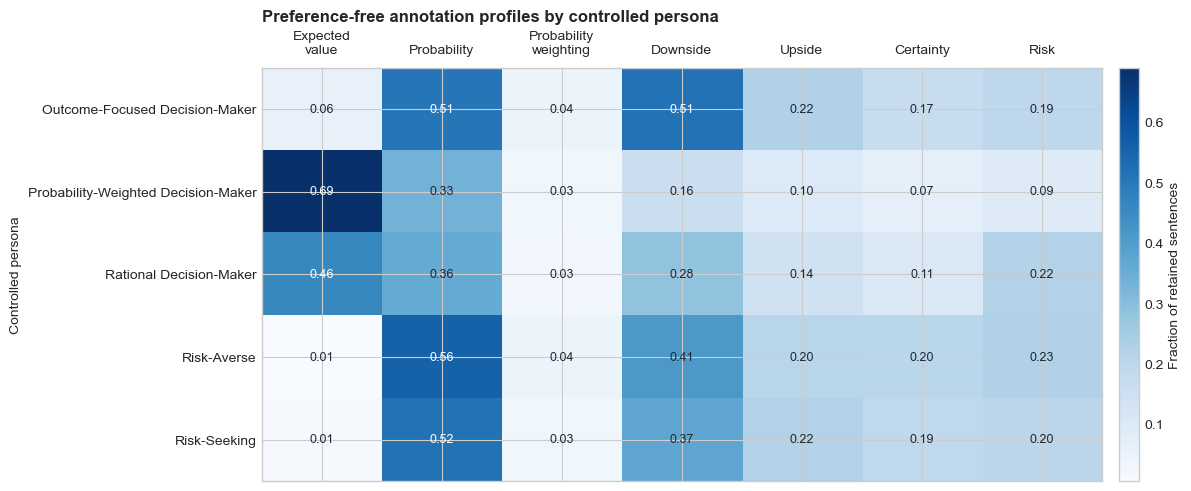

In [7]:
annotation_rows = []
for row in retained.itertuples():
    result = annotate_sentence(row.sentence_text)
    item = {
        "trial_row": row.trial_row,
        "question_id": row.question_id,
        "persona": row.persona,
        "choice": int(row.choice),
    }
    for label in CODEBOOK:
        item[label] = int(label in result["attended_information"])
    annotation_rows.append(item)

sentence_annotations = pd.DataFrame(annotation_rows)
annotation_profiles = (
    sentence_annotations.groupby(["trial_row", "question_id", "persona", "choice"])[list(CODEBOOK)]
    .mean()
    .reset_index()
)

persona_profile = annotation_profiles.groupby("persona")[list(CODEBOOK)].mean()
COLUMN_LABELS = {
    "expected_value": "Expected\nvalue",
    "probability": "Probability",
    "probability_weighting": "Probability\nweighting",
    "downside": "Downside",
    "upside": "Upside",
    "certainty": "Certainty",
    "risk": "Risk",
}
display(persona_profile.rename(columns=COLUMN_LABELS).round(3))

fig, ax = plt.subplots(figsize=(11.8, 4.8), layout="constrained")
image = ax.imshow(persona_profile.to_numpy(), aspect="auto", cmap="Blues")
ax.set_xticks(np.arange(len(CODEBOOK)))
ax.set_xticklabels([COLUMN_LABELS[name] for name in CODEBOOK], ha="center")
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False, pad=8)
ax.set_yticks(np.arange(len(persona_profile)))
ax.set_yticklabels(persona_profile.index)
ax.set_ylabel("Controlled persona")
ax.set_title("Preference-free annotation profiles by controlled persona", loc="left", weight="bold")
for row_index in range(persona_profile.shape[0]):
    for column_index in range(persona_profile.shape[1]):
        value = persona_profile.iloc[row_index, column_index]
        ax.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if value > 0.42 else "#1f2937",
            fontsize=9,
        )
fig.colorbar(image, ax=ax, label="Fraction of retained sentences", pad=0.02)
plt.show()

In [8]:
X_annotation = annotation_profiles[list(CODEBOOK)]
y_persona = annotation_profiles["persona"]
groups = annotation_profiles["question_id"]

persona_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
)
persona_prediction = cross_val_predict(
    persona_model,
    X_annotation,
    y_persona,
    groups=groups,
    cv=GroupKFold(n_splits=5),
)
persona_balanced_accuracy = balanced_accuracy_score(y_persona, persona_prediction)
print(f"Held-question persona balanced accuracy: {persona_balanced_accuracy:.3f}")
print(f"Five-class chance reference: {1 / y_persona.nunique():.3f}")

Held-question persona balanced accuracy: 0.519
Five-class chance reference: 0.200


## 4. Does the annotation add behavioral information?

Now test a downstream claim. We compare:

1. option features only;
2. preference-free annotation profiles only;
3. option features plus annotation profiles.

Evaluation holds out entire questions. This asks whether the coded process report carries information about choice beyond the displayed lotteries.

In [9]:
LOTTERY_PATTERN = re.compile(
    r"(-?\d+(?:\.\d+)?) dollars with (\d+(?:\.\d+)?) % chance"
)


def parse_option(question, label):
    segment = question.split(f"Option {label}:", 1)[1]
    if label == "A":
        segment = segment.split("Option B:", 1)[0]
    pairs = [(float(value), float(probability) / 100) for value, probability in LOTTERY_PATTERN.findall(segment)]
    probabilities = np.asarray([p for _, p in pairs], dtype=float)
    outcomes = np.asarray([v for v, _ in pairs], dtype=float)
    probabilities = probabilities / probabilities.sum()
    ev = float(np.sum(probabilities * outcomes))
    sd = float(np.sqrt(np.sum(probabilities * (outcomes - ev) ** 2)))
    best_index = int(np.argmax(outcomes))
    return {
        "ev": ev,
        "sd": sd,
        "worst": float(outcomes.min()),
        "best": float(outcomes.max()),
        "p_best": float(probabilities[best_index]),
        "p_zero": float(probabilities[np.isclose(outcomes, 0)].sum()),
        "certain": float(len(outcomes) == 1 or np.isclose(probabilities.max(), 1)),
    }


questions = sentences[["question_id", "question"]].drop_duplicates().copy()
feature_rows = []
for row in questions.itertuples():
    a = parse_option(row.question, "A")
    b = parse_option(row.question, "B")
    feature_rows.append({
        "question_id": row.question_id,
        **{f"{name}_diff": b[name] - a[name] for name in a},
    })
option_features = pd.DataFrame(feature_rows)

modeling = annotation_profiles.merge(option_features, on="question_id", how="left")
OPTION_COLUMNS = [column for column in option_features if column != "question_id"]
ANNOTATION_COLUMNS = list(CODEBOOK)


def grouped_choice_predictions(feature_columns):
    x = modeling[feature_columns]
    y = modeling["choice"].to_numpy()
    groups = modeling["question_id"].to_numpy()
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
    )
    probability = cross_val_predict(
        model,
        x,
        y,
        groups=groups,
        cv=GroupKFold(n_splits=5),
        method="predict_proba",
    )[:, 1]
    return {
        "balanced_accuracy": balanced_accuracy_score(y, probability >= 0.5),
        "log_loss": log_loss(y, probability),
        "probability": probability,
    }


model_sets = {
    "option features": OPTION_COLUMNS,
    "annotation profile": ANNOTATION_COLUMNS,
    "options + annotation": OPTION_COLUMNS + ANNOTATION_COLUMNS,
}
choice_results = []
prediction_cache = {}
for name, columns in model_sets.items():
    result = grouped_choice_predictions(columns)
    prediction_cache[name] = result["probability"]
    choice_results.append({
        "model": name,
        "n_features": len(columns),
        "balanced_accuracy": result["balanced_accuracy"],
        "log_loss": result["log_loss"],
    })

choice_table = pd.DataFrame(choice_results).sort_values("log_loss")
display(choice_table.round(3))

,model,n_features,balanced_accuracy,log_loss
1,annotation profile,7,0.619,0.673
2,options + annotation,14,0.587,0.720
0,option features,7,0.529,0.738


## 5. Translate annotations into restricted candidate models

Annotation is most useful for discovery when it nominates **computational ingredients**, not when it directly writes unrestricted code.

The mapping below is intentionally explicit. For example:

- expected-value language nominates `ev_diff`;
- downside and certainty language nominate `worst_diff`, `sd_diff`, and certainty;
- upside language nominates `best_diff` and the probability of the best outcome.

Trusted code maps approved ingredients to estimators. The language model never executes arbitrary Python.

In [10]:
ANNOTATION_TO_FEATURES = {
    "expected_value": ["ev_diff"],
    "probability": ["p_best_diff", "p_zero_diff"],
    "probability_weighting": ["p_best_diff", "p_zero_diff"],
    "downside": ["worst_diff", "sd_diff"],
    "upside": ["best_diff", "p_best_diff"],
    "certainty": ["certain_diff", "sd_diff"],
    "risk": ["sd_diff", "worst_diff"],
}

mean_annotation_rate = annotation_profiles[ANNOTATION_COLUMNS].mean().sort_values(ascending=False)
supported_ingredients = mean_annotation_rate.head(4).index.tolist()
selected_features = sorted({
    feature
    for ingredient in supported_ingredients
    for feature in ANNOTATION_TO_FEATURES[ingredient]
})

annotation_guided_spec = {
    "name": "annotation-guided candidate",
    "ingredients": supported_ingredients,
    "features": selected_features,
}
print(json.dumps(annotation_guided_spec, indent=2))

{
  "name": "annotation-guided candidate",
  "ingredients": [
    "probability",
    "downside",
    "expected_value",
    "risk"
  ],
  "features": [
    "ev_diff",
    "p_best_diff",
    "p_zero_diff",
    "sd_diff",
    "worst_diff"
  ]
}


In [11]:
candidate_specs = [
    {"name": "expected value", "features": ["ev_diff"]},
    {"name": "safety / downside", "features": ["worst_diff", "sd_diff", "certain_diff"]},
    {"name": "upside focus", "features": ["best_diff", "p_best_diff"]},
    {"name": annotation_guided_spec["name"], "features": annotation_guided_spec["features"]},
    {"name": "expanded option model", "features": OPTION_COLUMNS},
]

discovery_rows = []
discovery_probabilities = {}
for spec in candidate_specs:
    result = grouped_choice_predictions(spec["features"])
    discovery_probabilities[spec["name"]] = result["probability"]
    discovery_rows.append({
        "candidate": spec["name"],
        "n_features": len(spec["features"]),
        "balanced_accuracy": result["balanced_accuracy"],
        "log_loss": result["log_loss"],
    })

discovery_table = pd.DataFrame(discovery_rows).sort_values("log_loss")
display(discovery_table.round(3))

,candidate,n_features,balanced_accuracy,log_loss
2,upside focus,2,0.576,0.685
0,expected value,1,0.609,0.688
3,annotation-guided candidate,5,0.555,0.711
1,safety / downside,3,0.396,0.731
4,expanded option model,7,0.529,0.738


## 6. Implement a minimal propose-search-evaluate loop

The table above evaluates a hand-written candidate set. We now let **DeepSeek V4 Pro** propose and revise candidates, while keeping the scientific controls outside the language model.

We use one synthetic participant (`69576`) to mirror the participant-level design in the CCN model-discovery study:

- **training:** Q01-Q11; behavior and preference-free think-aloud are visible to DeepSeek;
- **validation:** Q12-Q15; Python fits and ranks proposed candidates;
- **test:** Q16-Q19; hidden until one candidate has been selected.

DeepSeek can select only from the seven approved decision variables. It cannot execute arbitrary code, inspect the test set, or directly choose the winner.

This compact design adapts the separation of proposal, fitting, held-out evaluation, and think-aloud-constrained search in [Xie et al., *Think-Aloud Reshapes Automated Cognitive Model Discovery Beyond Behavior* (CCN 2026)](https://arxiv.org/abs/2605.05091).

In [12]:
def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/LLM_human_decisions")]
    for candidate in candidates:
        if (candidate / "scripts/minimal_discovery_loop.py").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate scripts/minimal_discovery_loop.py")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.minimal_discovery_loop import (
    OUTPUT_DIR as DISCOVERY_OUTPUT_DIR,
    load_participant_trials,
    run_loop,
    split_trials,
)

discovery_trials = load_participant_trials()
discovery_splits = split_trials(discovery_trials)
split_summary = pd.DataFrame([
    {
        "split": name,
        "questions": ", ".join(frame["question_id"]),
        "n_trials": len(frame),
        "A choices": int((frame["choice_label"] == "A").sum()),
        "B choices": int((frame["choice_label"] == "B").sum()),
        "visible to DeepSeek": "behavior + think-aloud" if name == "train" else "no",
    }
    for name, frame in discovery_splits.items()
])
display(split_summary)
display(
    discovery_splits["train"][["question_id", "choice_label", "think_aloud"]]
    .head(3)
    .rename(columns={"choice_label": "observed_choice", "think_aloud": "preference_free_think_aloud"})
)

,split,questions,n_trials,A choices,B choices,visible to DeepSeek
0,train,"Q01, Q02, Q03, Q04, Q05, Q06, Q07, Q08, Q09, Q10, Q11",11,6,5,behavior + think-aloud
1,validation,"Q12, Q13, Q14, Q15",4,2,2,no
2,test,"Q16, Q17, Q18, Q19",4,2,2,no


,question_id,observed_choice,preference_free_think_aloud
0,Q01,A,"To make this decision, I'll calculate the expected value of each option. The expected value is the sum of the probab..."
1,Q02,A,"To make this decision, I need to calculate the expected values of both options. For Option A, the expected value is ..."
2,Q03,B,"First, I need to compute the expected values for both options. For Option A, the expected value would be calculated ..."


### Three search iterations, with the test set kept closed

The live path makes three API calls:

1. propose four candidate models from the training evidence;
2. show validation performance and errors, then request three revisions;
3. repeat the validation-guided revision once more to test whether search is
   still improving or has plateaued.

Python validates every JSON specification, fits its coefficients on training
behavior, and ranks it using validation log loss. Only after all three search
iterations do we select one candidate, refit it on training + validation, and
open the four test questions once. More rounds are possible, but every extra
round consumes validation information and can overfit the validation set.

Set `RUN_DEEPSEEK_DISCOVERY = True` to rerun the calls. The default uses the cached teaching run, so every student can inspect the complete loop without an API key.

In [13]:
# RESTORED_WORKFLOW: explicit_discovery
RUN_DEEPSEEK_DISCOVERY = False
DISCOVERY_CACHE = DISCOVERY_OUTPUT_DIR / "minimal_discovery_run.json"

from scripts.minimal_discovery_loop import (
    SEARCH_ITERATIONS,
    call_deepseek,
    fit_and_score,
    proposal_messages,
    revision_messages,
    validate_candidates,
    validation_record,
)


def run_visible_search_loop(splits):
    # 1. LLM proposes executable structures from training evidence.
    response = call_deepseek(proposal_messages(splits["train"]))
    candidates = validate_candidates(response["content"], expected_count=4)
    iterations = []

    # 2. Trusted Python fits parameters and evaluates validation behavior.
    for iteration in range(SEARCH_ITERATIONS):
        validation = [
            validation_record(
                fit_and_score(spec, splits["train"], splits["validation"])
            )
            for spec in candidates
        ]
        iterations.append({
            "iteration": iteration,
            "stage": "initial proposal" if iteration == 0 else f"revision {iteration}",
            "response": response,
            "candidates": candidates,
            "validation": validation,
        })
        if iteration < SEARCH_ITERATIONS - 1:
            # 3. Only validation evidence is returned to the LLM for revision.
            response = call_deepseek(
                revision_messages(splits["train"], candidates, validation)
            )
            candidates = validate_candidates(response["content"], expected_count=3)

    # 4. Selection happens before test is opened.
    all_validation = [row for item in iterations for row in item["validation"]]
    winner = min(all_validation, key=lambda row: row["validation_log_loss"])
    final_spec = {key: winner[key] for key in [
        "name", "features", "process_hypothesis", "trace_evidence"
    ]}
    train_plus_validation = pd.concat(
        [splits["train"], splits["validation"]], ignore_index=True
    )
    final_test = fit_and_score(final_spec, train_plus_validation, splits["test"])
    return {
        "design": {
            "search_iterations": SEARCH_ITERATIONS,
            "test_access": "opened once after candidate selection",
        },
        "search_iterations": iterations,
        "selected_model": final_spec,
        "test_result": final_test,
        "test_baselines": [],
    }


if RUN_DEEPSEEK_DISCOVERY:
    # Use the canonical implementation for the full baseline suite and saved audit log.
    discovery_run = run_loop()
    DISCOVERY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    DISCOVERY_CACHE.write_text(
        json.dumps(discovery_run, indent=2, ensure_ascii=False), encoding="utf-8"
    )
else:
    discovery_run = json.loads(DISCOVERY_CACHE.read_text(encoding="utf-8"))

print("Search iterations:", len(discovery_run["search_iterations"]))
for iteration in discovery_run["search_iterations"]:
    print(iteration["stage"], "->", iteration["response"]["model"])
print("Test access:", discovery_run["design"]["test_access"])

Search iterations: 3
initial proposal -> deepseek-v4-pro
revision 1 -> deepseek-v4-pro
revision 2 -> deepseek-v4-pro
Test access: opened once after candidate selection


In [14]:
validation_frames = []
for iteration in discovery_run["search_iterations"]:
    validation_frames.append(
        pd.DataFrame(iteration["validation"]).assign(
            iteration=iteration["iteration"],
            stage=iteration["stage"],
        )
    )

validation_view = pd.concat(validation_frames, ignore_index=True)
validation_view["features"] = validation_view["features"].map(", ".join)
validation_view = validation_view[
    ["iteration", "stage", "name", "features", "validation_balanced_accuracy", "validation_log_loss"]
].sort_values(["iteration", "validation_log_loss"])
display(validation_view.round(3))

print("Selected before opening test:")
print(json.dumps(discovery_run["selected_model"], indent=2))

,iteration,stage,name,features,validation_balanced_accuracy,validation_log_loss
2,0,initial proposal,Minimize probability of loss,"p_zero_diff, ev_diff",0.75,0.663
0,0,initial proposal,Expected value maximizer,ev_diff,0.50,0.680
3,0,initial proposal,Worst outcome avoidance,"worst_diff, ev_diff",0.75,0.683
1,0,initial proposal,"Risk aversion in gains, risk seeking in losses","ev_diff, sd_diff, certain_diff",0.50,0.918
4,1,revision 1,Minimize probability of loss with EV,"p_zero_diff, ev_diff",0.75,0.663
6,1,revision 1,EV and probability of zero combined,"ev_diff, p_zero_diff, worst_diff",0.50,0.667
5,1,revision 1,Worst outcome avoidance with EV,"worst_diff, ev_diff",0.75,0.683
7,2,revision 2,Minimize probability of loss with EV,"p_zero_diff, ev_diff",0.75,0.663
9,2,revision 2,EV and probability of zero combined,"ev_diff, p_zero_diff, worst_diff",0.50,0.667
8,2,revision 2,Worst outcome avoidance with EV,"worst_diff, ev_diff",0.75,0.683


Selected before opening test:
{
  "name": "Minimize probability of loss",
  "features": [
    "p_zero_diff",
    "ev_diff"
  ],
  "process_hypothesis": "Choices are driven by minimizing the probability of experiencing a loss, especially when expected values are similar or equal.",
  "trace_evidence": "In Q09, the participant notes that Option A has a lower risk of losing money (55% chance of no loss vs 10% for B) and chooses A despite equal EV. In Q04, the participant chooses B because the potential loss is smaller, but also notes the probability of zero is higher in B (50% vs 75%? Actually B has 50% zero, A has 75% zero, so this contradicts; but the participant focuses on worst outcome). However, in Q02, the participant chooses A because of the 20% chance to lose nothing, which is a higher p"
}


In [15]:
test_rows = [discovery_run["test_result"], *discovery_run["test_baselines"]]
test_view = pd.DataFrame([
    {
        "model": row["name"],
        "features": ", ".join(row["features"]),
        "parameters": row["n_parameters"],
        "test_balanced_accuracy": row["balanced_accuracy"],
        "test_log_loss": row["log_loss"],
    }
    for row in test_rows
]).sort_values("test_log_loss")
display(test_view.round(3))

print(
    "Teaching result: the DeepSeek-selected candidate wins validation but does not "
    "beat the comparison baselines on four test trials. Two revision rounds also "
    "plateau at the same validation loss. This is a runnable search "
    "loop, not evidence of mechanism recovery."
)

,model,features,parameters,test_balanced_accuracy,test_log_loss
4,all-feature baseline,"ev_diff, sd_diff, worst_diff, best_diff, p_best_diff, p_zero_diff, certain_diff",8,1.00,0.248
3,expected-value baseline,ev_diff,2,0.75,0.453
0,Minimize probability of loss,"p_zero_diff, ev_diff",3,0.50,0.534
5,best single-feature (best_diff),best_diff,2,0.75,0.607
1,random 0.5,,0,0.50,0.693
2,training choice-rate,,0,0.50,0.695


Teaching result: the DeepSeek-selected candidate wins validation but does not beat the comparison baselines on four test trials. Two revision rounds also plateau at the same validation loss. This is a runnable search loop, not evidence of mechanism recovery.


## 7. Use disagreement to design the next test

A candidate model becomes scientifically useful when it produces predictions that can be separated from alternatives. We therefore search for questions where the candidate probabilities disagree most.

In [16]:
candidate_probability_frame = pd.DataFrame(discovery_probabilities)
candidate_probability_frame["question_id"] = modeling["question_id"].to_numpy()
candidate_probability_frame["spread"] = (
    candidate_probability_frame[list(discovery_probabilities)].max(axis=1)
    - candidate_probability_frame[list(discovery_probabilities)].min(axis=1)
)

diagnostic = (
    candidate_probability_frame.groupby("question_id")["spread"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .rename("mean_candidate_disagreement")
    .reset_index()
    .merge(questions, on="question_id", how="left")
)
display(diagnostic)

,question_id,mean_candidate_disagreement,question
0,Q08,0.510481,"Which option do you prefer? Option A: 4000.0 dollars with 80.0 % chance, 0.0 dollars with 20.0 % chance. Option B: 3..."
1,Q10,0.474279,"Which option do you prefer? Option A: -5000.0 dollars with 0.1 % chance, 0.0 dollars with 99.9 % chance. Option B: -..."
2,Q18,0.464092,"Which option do you prefer? Option A: -4000.0 dollars with 80.0 % chance, 0.0 dollars with 20.0 % chance. Option B: ..."
3,Q05,0.449801,"Which option do you prefer? Option A: 5000.0 dollars with 0.1 % chance, 0.0 dollars with 99.9 % chance. Option B: 5...."
4,Q14,0.404225,"Which option do you prefer? Option A: 6000.0 dollars with 45.0 % chance, 0.0 dollars with 55.0 % chance. Option B: 3..."


## 8. The integrated evidence loop

The implemented search loop now has an auditable structure:

```text
training behavior + masked reasoning traces
    -> DeepSeek proposes restricted candidate specifications
    -> trusted Python fits parameters on training behavior
    -> validation feedback guides one revision
    -> select one candidate before opening the test set
    -> evaluate once on frozen test questions
```

The earlier annotation-to-candidate route is one possible subloop:

```text
masked reasoning traces
    → annotate information and operations
    → validate annotation stability and construct sensitivity
    → nominate restricted computational ingredients
    → fit candidate models on behavior
    → evaluate on held-out questions
    → inspect model–annotation disagreements
    → design the next diagnostic trial
```

A compact Bayesian statement is:

\[
p(M \mid C,E) \propto p(C \mid M)\,p(E \mid M)\,p(M),
\]

where \(C\) is choice evidence and \(E\) is process evidence. This factorization is a modeling assumption, not a free guarantee of independence.

## What this notebook establishes—and what it does not

**Supported if the controls succeed**

- reasoning annotations detect a controlled synthetic manipulation;
- preference-free process annotations contain held-question choice information;
- annotations can restrict a transparent candidate-model search;
- a minimal proposal-revision-evaluation loop can be audited end to end;
- candidate disagreement identifies useful diagnostic questions.

**Not established**

- that an annotation is the true causal process;
- that a prompted GPT-4 persona is equivalent to a human strategy;
- that the best predictive candidate recovered the generating primitives;
- that adding process evidence removes model non-identifiability.

## Classroom exercises

1. Add one annotation label and define its falsifier.
2. Compare the lexical baseline with one language-model annotator on 30 sentences.
3. Repeat the analysis after shuffling annotations across trials within each question.
4. Remove one candidate family and observe how the proposed diagnostic questions change.